In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

In [30]:
"""
7. Attribute information

Date : year-month-day
Rented Bike count - Count of bikes rented at each hour
Hour - Hour of he day
Temperature-Temperature in Celsius
Humidity - %
Windspeed - m/s
Visibility - 10m
Dew point temperature - Celsius 
Solar radiation - MJ/m2
Rainfall - mm
Snowfall - cm
Seasons - Winter, Spring, Summer, Autumn
Holiday - Holiday/No holiday
Functional Day - NoFunc(Non Functional Hours), Fun(Functional hours)

"""


# --- Load dataset ---
df = pd.read_csv("data/raw/SeoulBikeData.csv", encoding='unicode_escape')
df.head()


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [31]:
# drop columns with >  50% missing values
missing_threshold = 0.5
mask_missing = df.isnull().mean() < missing_threshold
df = df.loc[:, mask_missing]

# --- Simple preprocessing ---
df = df.dropna()
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
#df = pd.get_dummies(df, drop_first=True)

feature_cols = [x for x in df.columns if x not in ["Date","Rented Bike Count"]]
linear_feature_cols = [x for x in feature_cols if x not in ["Holiday", "Seasons", "Functional Day"]]
y = df["Rented Bike Count"]


In [32]:


X = df[feature_cols]
X = pd.get_dummies(X, drop_first=True)
# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Scale for logistic regression ---
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print('\nModel Comparison (Temporal Validation):')
print(f'Linear Regression - MAE: {lr_mae:.2f}, RMSE: {lr_rmse:.2f}')
print(f'Random Forest      - MAE: {rf_mae:.2f}, RMSE: {rf_rmse:.2f}')


Model Comparison (Temporal Validation):
Linear Regression - MAE: 330.39, RMSE: 440.78
Random Forest      - MAE: 144.72, RMSE: 240.28


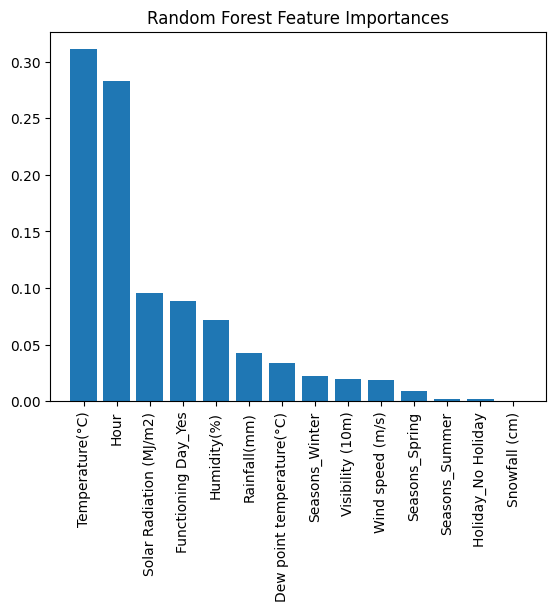

In [35]:
# plot random forest feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure()
plt.title("Random Forest Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.show()

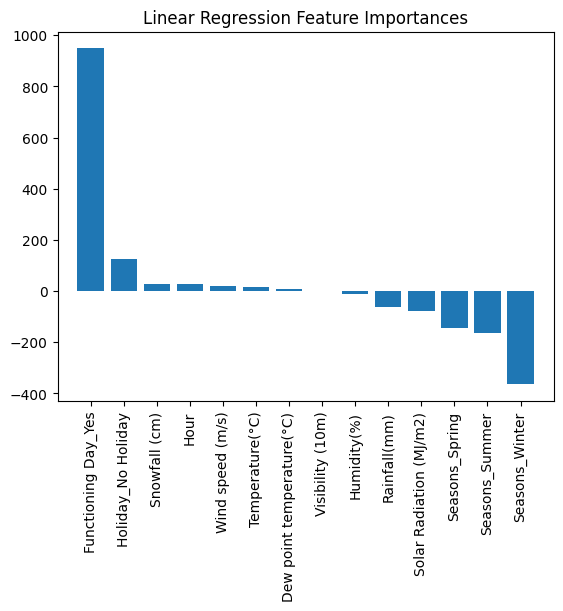

In [36]:
## plot linear regression feature importances
importances = lr.coef_
indices = np.argsort(importances)[::-1]

plt.figure()
plt.title("Linear Regression Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.show()


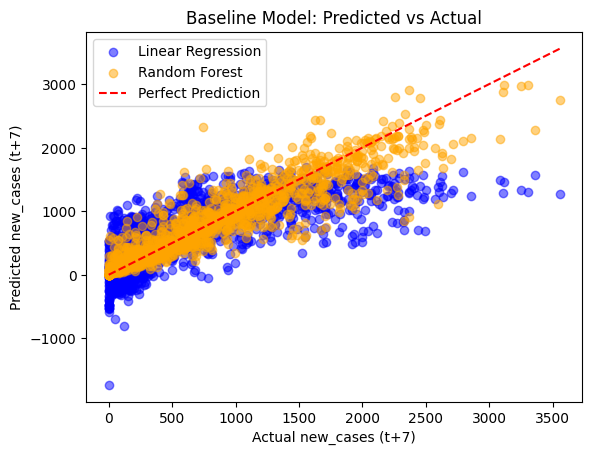

In [37]:

plt.scatter(y_test, lr_pred, alpha=0.5, color='blue', label='Linear Regression')
plt.scatter(y_test, rf_pred, alpha=0.5, color='orange', label='Random Forest')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual new_cases (t+7)')
plt.ylabel('Predicted new_cases (t+7)')
plt.title('Baseline Model: Predicted vs Actual')
plt.legend()
plt.show()